In [4]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Absolute path - always works regardless of where Jupyter launched from
DB_PATH = str(Path.home() / "Downloads/berlin-analytics-warehouse/data/processed/warehouse.duckdb")
OUTPUT_PATH = Path.home() / "Downloads/berlin-analytics-warehouse/data/processed"

con = duckdb.connect(DB_PATH)
sns.set_theme(style="whitegrid")
print("✅ Connected to warehouse!")

✅ Connected to warehouse!


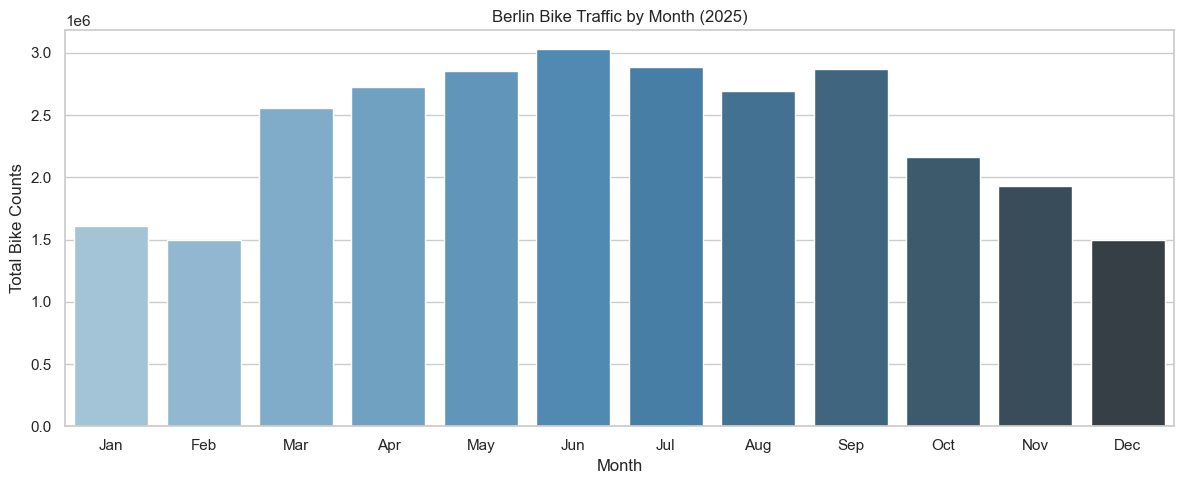

✅ Chart saved!


In [5]:
monthly = con.execute("""
    SELECT d.month, SUM(f.bike_count) AS total_bikes
    FROM fact_bike_counts f
    JOIN dim_date d ON f.date_id = d.date_id
    GROUP BY d.month ORDER BY d.month
""").df()

monthly['month_name'] = pd.to_datetime(monthly['month'], format='%m').dt.strftime('%b')

plt.figure(figsize=(12, 5))
sns.barplot(data=monthly, x='month_name', y='total_bikes', hue='month_name', palette='Blues_d', legend=False)
plt.title('Berlin Bike Traffic by Month (2025)')
plt.xlabel('Month')
plt.ylabel('Total Bike Counts')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'monthly_trend.png', dpi=150)
plt.show()
print("✅ Chart saved!")

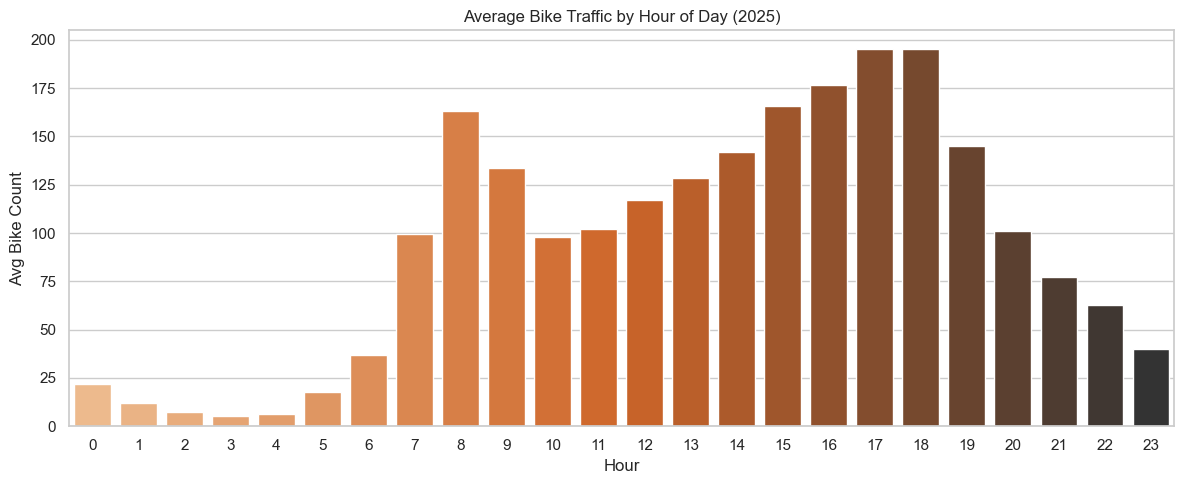

✅ Saved!


In [6]:
hourly = con.execute("""
    SELECT hour, AVG(bike_count) AS avg_bikes
    FROM fact_bike_counts
    GROUP BY hour ORDER BY hour
""").df()

plt.figure(figsize=(12, 5))
sns.barplot(data=hourly, x='hour', y='avg_bikes', hue='hour', palette='Oranges_d', legend=False)
plt.title('Average Bike Traffic by Hour of Day (2025)')
plt.xlabel('Hour')
plt.ylabel('Avg Bike Count')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'hourly_pattern.png', dpi=150)
plt.show()
print("✅ Saved!")

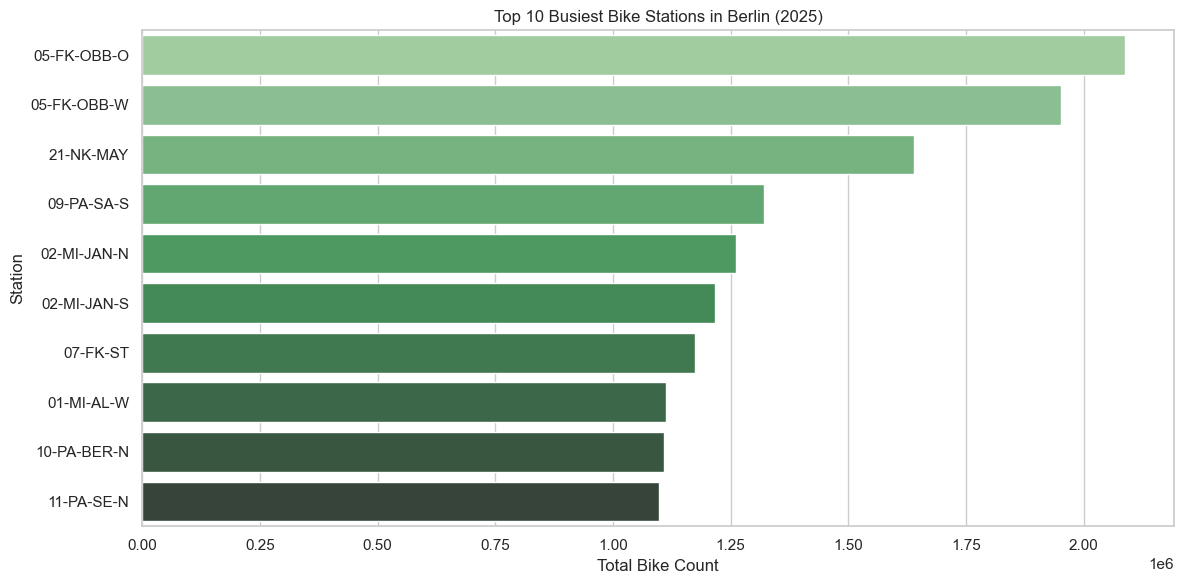

✅ Saved!


In [7]:
top_stations = con.execute("""
    SELECT station_name, SUM(bike_count) AS total_bikes
    FROM fact_bike_counts
    GROUP BY station_name
    ORDER BY total_bikes DESC
    LIMIT 10
""").df()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_stations, y='station_name', x='total_bikes', hue='station_name', palette='Greens_d', legend=False)
plt.title('Top 10 Busiest Bike Stations in Berlin (2025)')
plt.xlabel('Total Bike Count')
plt.ylabel('Station')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'top_stations.png', dpi=150)
plt.show()
print("✅ Saved!")

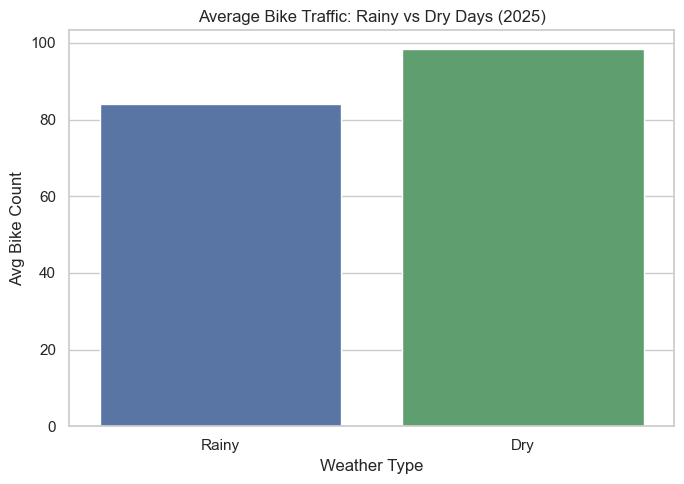

✅ Saved!


In [9]:
rain = con.execute("""
    SELECT
        CASE WHEN w.total_precipitation_mm > 1 THEN 'Rainy' ELSE 'Dry' END AS weather_type,
        AVG(f.bike_count) AS avg_bikes
    FROM fact_bike_counts f
    JOIN dim_weather w ON f.date_id = w.date_id
    GROUP BY weather_type
""").df()

plt.figure(figsize=(7, 5))
sns.barplot(data=rain, x='weather_type', y='avg_bikes', hue='weather_type', palette=['#4C72B0', '#55A868'], legend=False)
plt.title('Average Bike Traffic: Rainy vs Dry Days (2025)')
plt.xlabel('Weather Type')
plt.ylabel('Avg Bike Count')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'rain_vs_dry.png', dpi=150)
plt.show()
print("✅ Saved!")